# 📋 Notebook 1: Data Audit
**Project:** TalentSight — Employee Attrition Intelligence Platform  
**Author:** Saheri  
**Date:** May 2026  

## Objective
Before any cleaning, modelling, or analysis, we conduct a structured audit of the 
IBM HR Analytics dataset to answer one question:  
*"What exactly do we have, and what is wrong with it?"*

This notebook is diagnostic only — we observe and document. No data is modified here.
All remediation decisions are executed in `02_data_cleaning.ipynb`.

## 1. Setup & Data Loading
Import all required libraries and load the raw IBM HR Analytics dataset from the 
`data/raw/` directory. No transformations are applied at this stage.

In [1]:
#Import necessary libraries
import os
import pandas as pd
import numpy as np    
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset   
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
data = pd.read_csv(os.path.join(BASE_DIR, '..', 'data', 'raw', 'WA_Fn-UseC_-HR-Employee-Attrition.csv'))

In [3]:
#First 5 rows of the dataset
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Finding: Initial Inspection
The dataset contains employee-level records with a mix of demographic, compensation, 
job characteristics, and satisfaction survey fields. The target variable `Attrition` 
is visible as a string column (Yes/No) and will need to be binary-encoded in the 
cleaning phase. Note that `EmployeeCount` and `StandardHours` appear constant 
across all visible rows — this will be confirmed in the unique value check below.

In [4]:
#Shape of the datset
data.shape

(1470, 35)

### Finding: Dataset Dimensions
1,470 employee records across 35 columns. This is a manageable size for ML modelling 
but small enough that class imbalance (confirmed below) will meaningfully affect 
model training. No train/test split is applied yet.

## 2. Basic Overview of Dataset
We examine data types, null counts, descriptive statistics, duplicates, and unique 
value counts to build a complete picture of the dataset's structure and quality.

In [5]:
#Basic information about the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

### Finding: Data Types
26 columns are `int64` and 9 are string (`object`). However, several `int64` columns 
are not truly continuous numeric — they are **ordinal scales** (e.g., `JobSatisfaction` 
1–4, `Education` 1–5). These must not be treated as continuous variables in modelling. 
Full list of ordinal columns identified below.

No null values appear in the Non-Null Count column — confirmed cleanly in the 
isnull check further below.

In [6]:
#Descriptive Statistics of the dataset
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


### Finding: Descriptive Statistics — Key Observations

1. **`EmployeeCount`**: mean=1.0, std=0.0, min=max=1. Constant column — zero 
   predictive value. Will be dropped.
   
2. **`StandardHours`**: mean=80.0, std=0.0. Constant column — HRIS export artifact. 
   Will be dropped.
   
3. **`Over18`**: unique=1, top='Y'. All employees are over 18 with no exceptions. 
   Will be dropped.

4. **`MonthlyIncome`**: ranges from 1,009 to 19,999 with mean 6,502 and high std 
   of 4,707 — strong right skew expected. Outliers flagged in IQR analysis below.

5. **`PerformanceRating`**: min=3, max=4 despite being a supposed 1–4 scale. 
   Near-zero variance — will be treated with caution in feature engineering.

6. **`YearsSinceLastPromotion`**: 75th percentile is 3 years but max is 15 — 
   likely right-skewed with meaningful outliers worth investigating in EDA.

In [7]:
#Checking for null values in the dataset
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Finding: No Missing Values in Base Dataset
The IBM dataset is clean with zero nulls across all 35 columns. 

**Important caveat:** This will change in later phases. When we join this base 
table with the BLS API time-series and synthetic payroll data, left joins will 
introduce NaN rows (~12% estimated) due to sector mapping mismatches and 
date alignment gaps. Missing value handling will be addressed in `02_data_cleaning.ipynb`
after all sources are merged.

In [8]:
#Checking for duplicate values in the dataset
data.duplicated().sum()

np.int64(0)

### Finding: No Duplicate Rows
Zero duplicate records confirmed. Each row represents a unique employee. 
`EmployeeNumber` has 1,470 unique values matching the row count — confirms 
it can serve as a unique identifier for joining with external data sources.

In [9]:
#Checking for unique values in the dataset 
data.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

### Finding: Unique Value Analysis — Three Columns Flagged for Dropping

| Column | Unique Values | Verdict |
|---|---|---|
| `EmployeeCount` | 1 | ❌ Drop — constant, zero variance |
| `Over18` | 1 | ❌ Drop — constant, HRIS artifact |
| `StandardHours` | 1 | ❌ Drop — constant, HRIS artifact |
| `PerformanceRating` | 2 | ⚠️ Flag — near-constant, only values 3 & 4 |
| `EmployeeNumber` | 1470 | ℹ️ Keep as ID for joins, drop before modelling |

Additionally, the following columns are **ordinal scales encoded as integers** — 
they are NOT continuous and must be handled accordingly:
`Education`, `EnvironmentSatisfaction`, `JobInvolvement`, `JobLevel`, 
`JobSatisfaction`, `PerformanceRating`, `RelationshipSatisfaction`, 
`StockOptionLevel`, `WorkLifeBalance`

In [10]:
#Checking for outliers in the datset using IQR method
Q1 = data.select_dtypes(include=np.number).quantile(0.25)
Q3=data.select_dtypes(include=np.number).quantile(0.75)
IQR=Q3-Q1
Outliers=data[(data.select_dtypes(include=np.number)<Q1-1.5*IQR) | (data.select_dtypes(include=np.number)>Q3+1.5*IQR)]
#Check the number of outliers in the dataset in each columns
Outliers_count=Outliers.count()
print(Outliers_count)

Age                           0
Attrition                     0
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome               114
MonthlyRate                   0
NumCompaniesWorked           52
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating           226
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel             85
TotalWorkingYears            63
TrainingTimesLastYear       238
WorkLifeBalance               0
YearsAtC

### Finding: Outliers Detected via IQR Method

| Column | Outlier Count | Business Interpretation |
|---|---|---|
| `MonthlyIncome` | 114 | High earners — expected in salary distributions, not errors |
| `NumCompaniesWorked` | 52 | Employees with 8–9 prior companies — unusual but plausible |
| `PerformanceRating` | 226 | Artefact of near-zero variance — not true outliers |
| `YearsSinceLastPromotion` | 107 | Stalled careers — business-relevant signal, not errors |
| `YearsInCurrentRole` | 21 | Long tenure in same role — relevant attrition signal |
| `YearsWithCurrManager` | 14 | Long manager relationships — retain for analysis |

**Decision:** These are not data entry errors — they are real business patterns. 
We will **not cap or remove** these outliers. Instead, we will apply log transformation 
to right-skewed columns (`MonthlyIncome`, `YearsSinceLastPromotion`) during 
feature engineering to reduce their influence on distance-based models.

## 3. Distribution Analysis
We examine the distribution of the target variable, all numerical features, 
and all categorical features. The goal is to identify skew, imbalance, 
and anomalies that will inform our cleaning and feature engineering decisions.

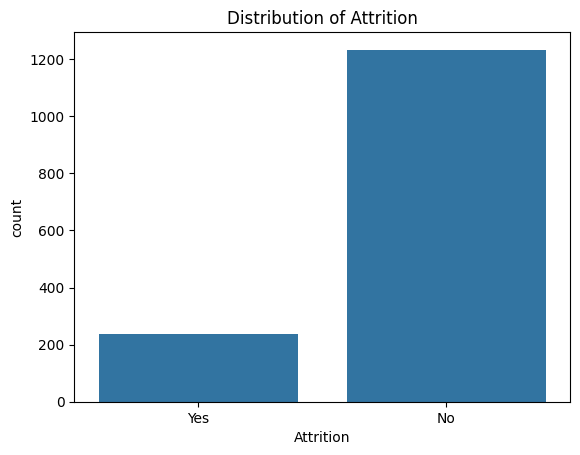

In [11]:
#Checking Distribution of the target variable 
sns.countplot(x='Attrition',data=data)
plt.title('Distribution of Attrition')
plt.show()

### Finding: Significant Class Imbalance in Target Variable
237 employees left (Yes) vs 1,233 who stayed (No) — a **16.1% attrition rate**.

This 84:16 imbalance means a naive model that predicts "No" for every employee 
achieves 84% accuracy while being completely useless for the actual business goal. 

**Action in modelling phase:** We will use `class_weight='balanced'` in XGBoost 
and evaluate using AUC-ROC and Precision-Recall AUC — not accuracy. 
Classification threshold will be tuned using business cost logic rather than 
maximising F1.

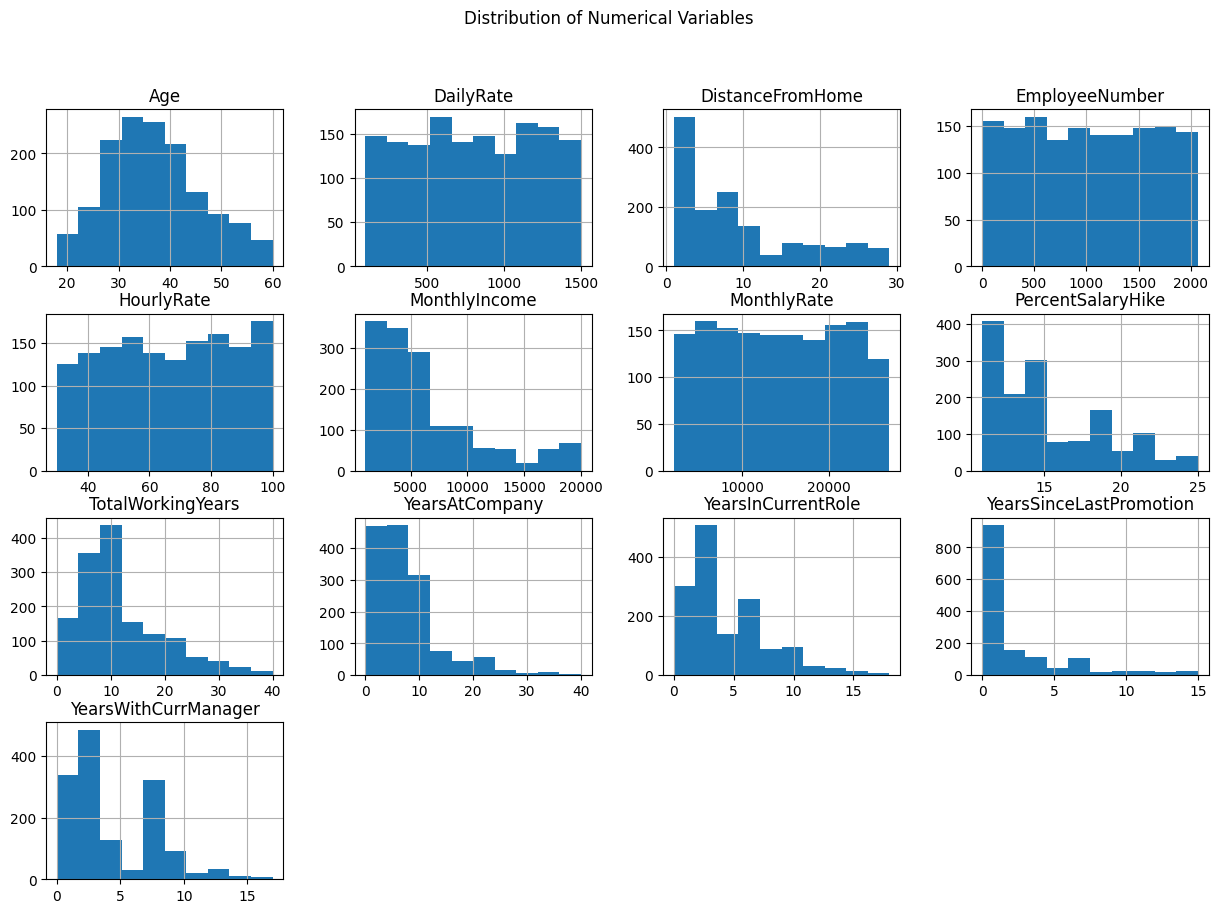

In [12]:
#Checking the distribution of numerical variables using histograms
numerical_cols=data.select_dtypes(include=np.number).columns
numerical_cols=[col for col in numerical_cols if data[col].nunique()>10]
data[numerical_cols].hist(figsize=(15,10))
plt.suptitle('Distribution of Numerical Variables')
plt.show()


### Finding: Numerical Distribution Summary

- **`MonthlyIncome`**: Strong right skew — majority of employees earn below 10,000 
  with a long tail of high earners. Log transformation recommended before modelling.
  
- **`YearsSinceLastPromotion`**: Heavily right-skewed — most employees were promoted 
  recently (0–1 years) but a significant tail extends to 15 years. This "promotion 
  stagnation" pattern is a known attrition predictor and will be a key feature.

- **`DistanceFromHome`**: Right-skewed — majority live close to work (1–5 km) 
  with a tail extending to 29 km. May interact with OverTime as a combined 
  stress indicator.

- **`Age`, `TotalWorkingYears`, `YearsAtCompany`**: All show expected right skew 
  for workforce distributions — more junior/mid employees than senior ones.
  
- **`HourlyRate`, `DailyRate`, `MonthlyRate`**: Roughly uniform distributions — 
  these three rate fields are inconsistent with each other and with `MonthlyIncome`. 
  They appear to be independent survey fields, not mathematically related. 
  Treat as separate features, not as components of a salary calculation.

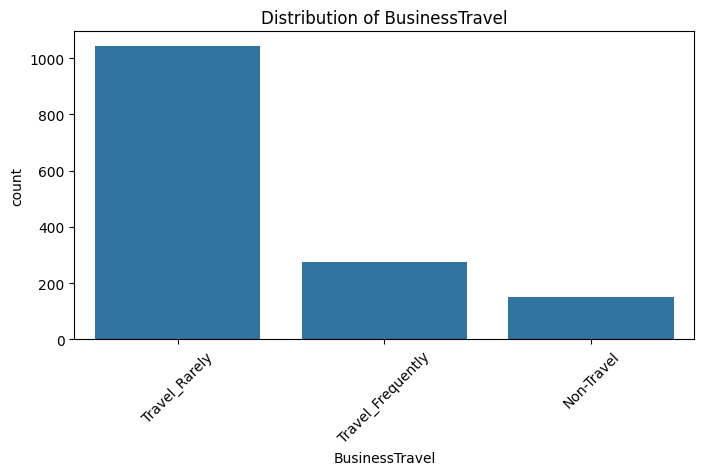

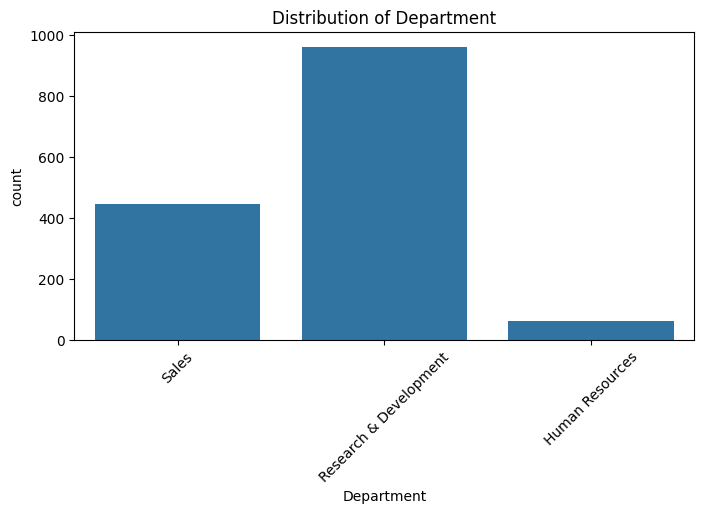

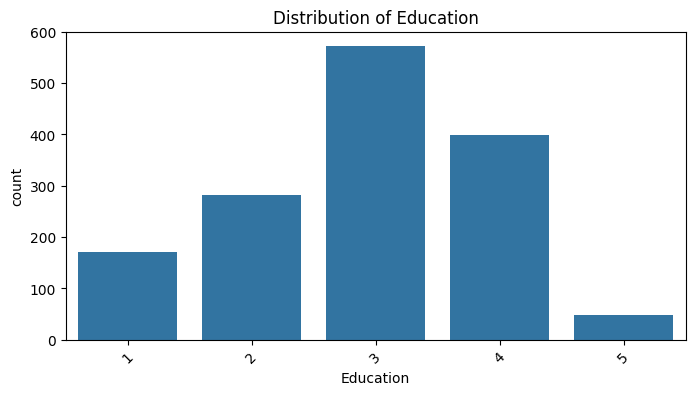

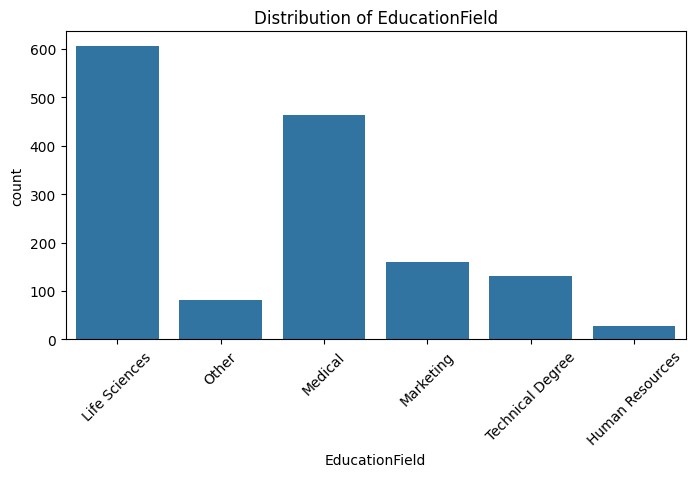

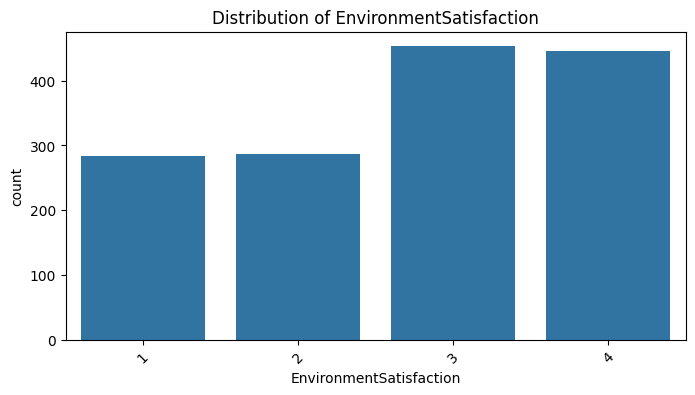

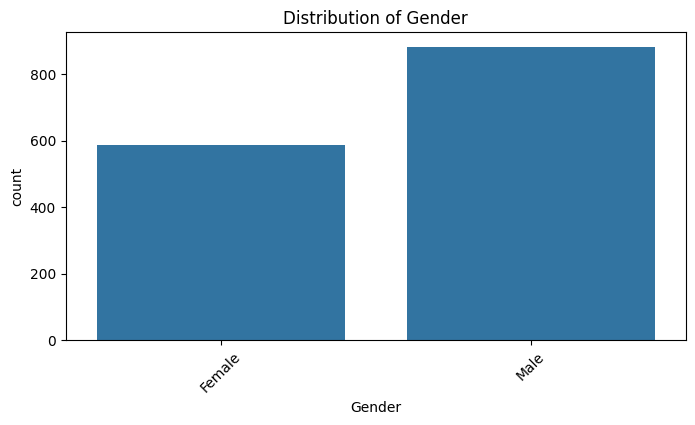

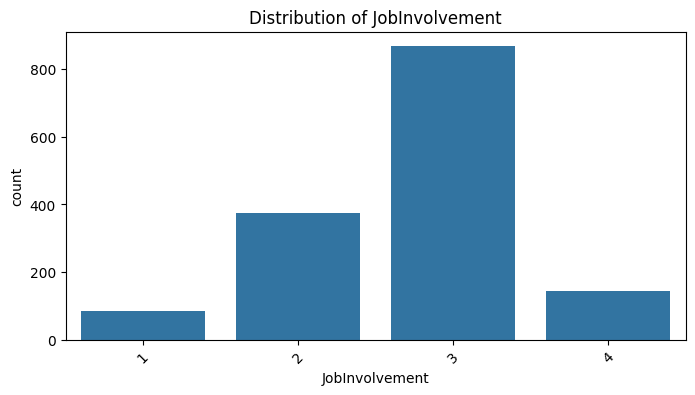

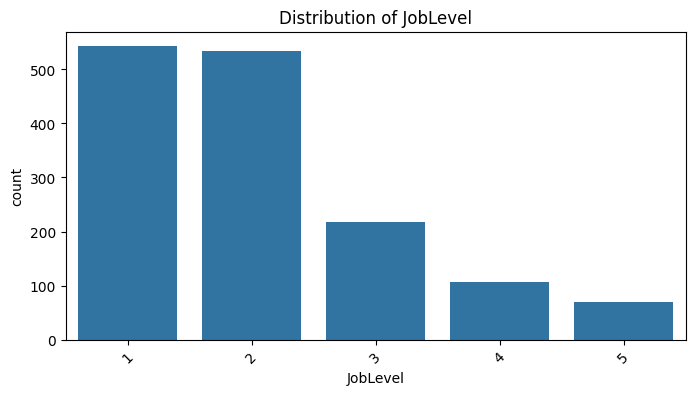

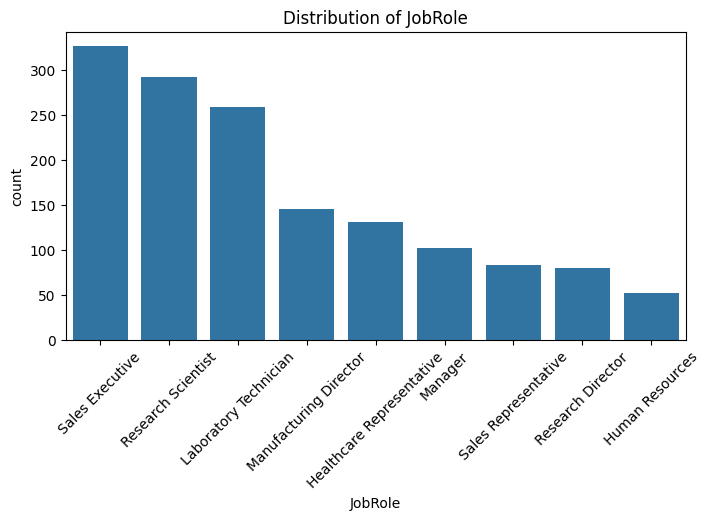

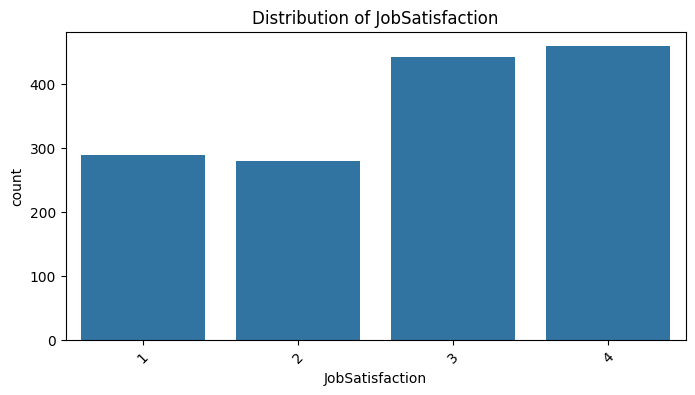

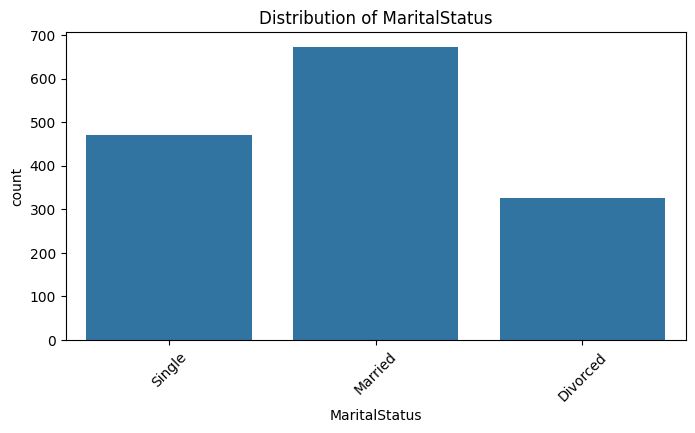

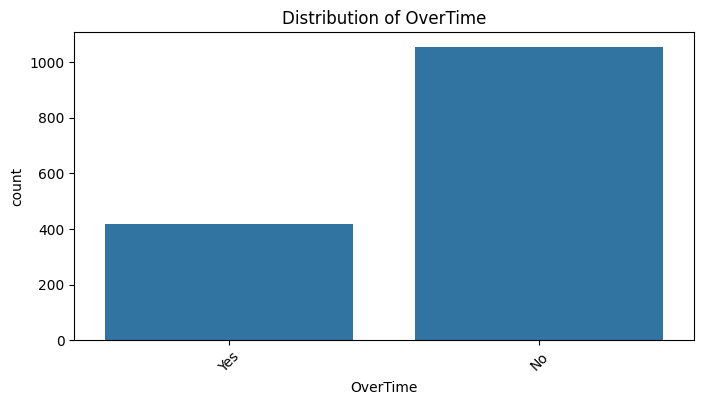

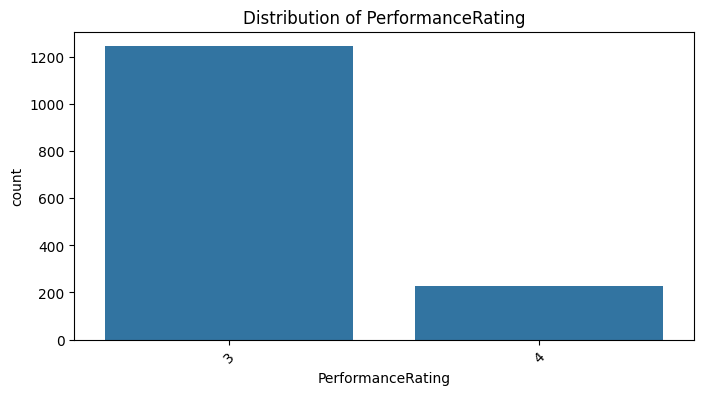

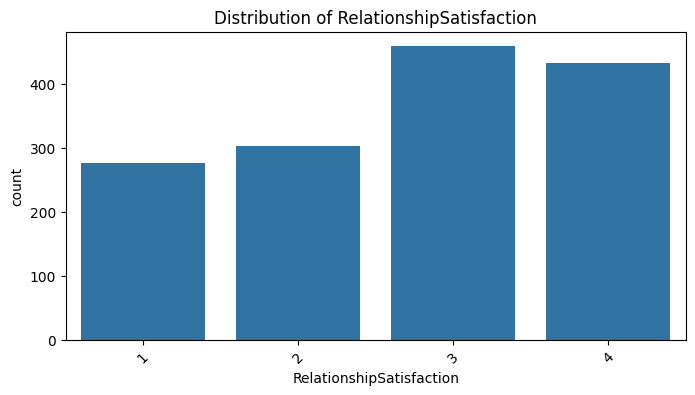

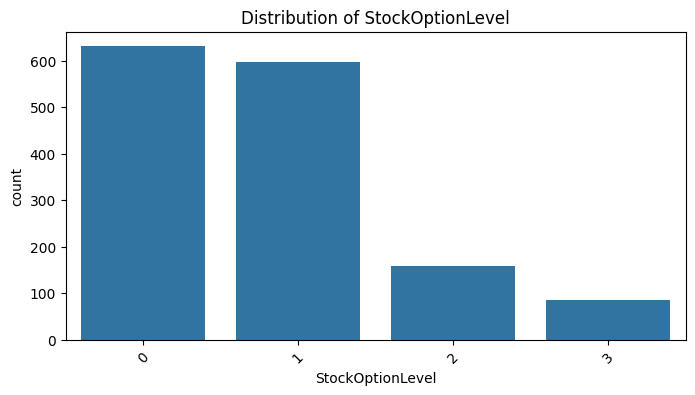

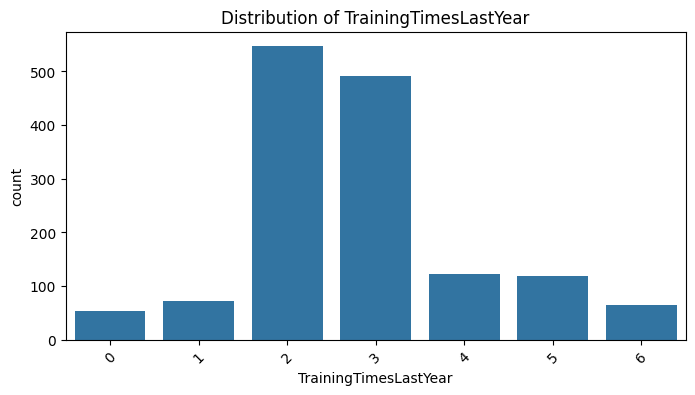

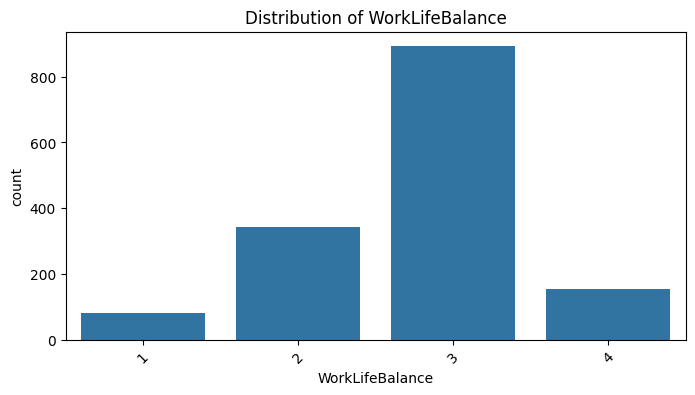

In [13]:
#Checking the distribution of categorical variables using countplots
categorical_cols=data.columns
categorical_cols=[col for col in categorical_cols if data[col].nunique()<10 and data[col].nunique()>1 and col!='Attrition']
#Plotting countplots for categorical variables
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col,data=data)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

### Finding: Categorical Distribution Summary

- **`OverTime`**: 28% of employees work overtime (416 Yes vs 1,054 No). 
  Given that overtime is one of the strongest known attrition predictors, 
  this imbalance is business-significant — not just a data characteristic.

- **`BusinessTravel`**: 71% rarely travel, 19% travel frequently, 10% non-travel. 
  Travel_Frequently employees will be a key attrition risk segment to investigate in EDA.

- **`Department`**: R&D dominates at 65%, Sales at 30%, HR at 4%. 
  Department-level attrition rates will vary significantly — firm-wide averages 
  will mask important segment differences.

- **`JobRole`**: Sales Executive (326) and Research Scientist (295) are the 
  largest roles. Human Resources (52) is the smallest. Role-level attrition 
  analysis will be central to the EDA.

- **`PerformanceRating`**: Only values 3 and 4 present despite a 1–4 scale. 
  This column has near-zero discriminative power and will be flagged for 
  potential exclusion during feature selection.

- **`StockOptionLevel`**: 43% of employees have no stock options (level 0). 
  Given the known relationship between equity compensation and retention, 
  this distribution makes `StockOptionLevel` a high-priority feature.

## 4. Data Audit Summary

| Check | Finding | Action |
|---|---|---|
| Shape | 1,470 rows × 35 columns | — |
| Missing values | None in base dataset | Will appear after multi-source joins |
| Duplicates | None | — |
| Constant columns | `EmployeeCount`, `Over18`, `StandardHours` | ❌ Drop in cleaning |
| Near-constant | `PerformanceRating` (only 3 & 4) | ⚠️ Flag for feature engineering |
| Class imbalance | 84% No / 16% Yes | Use SMOTE or `class_weight` in modelling |
| Ordinal as int64 | 9 columns | Document — handle in feature engineering |
| Outliers | `MonthlyIncome` (114), `YearsSinceLastPromotion` (107) | Retain — apply log transform |
| High-signal features | `OverTime`, `StockOptionLevel`, `YearsSinceLastPromotion` | Prioritise in EDA |

---

### Audit complete. No data has been modified in this notebook.
**Next:** `02_data_cleaning.ipynb` — drop constants, fix dtypes, encode target variable, 
document every decision with business justification.